In [53]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import stumpy
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 16, 5
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


np.float64(84.0)

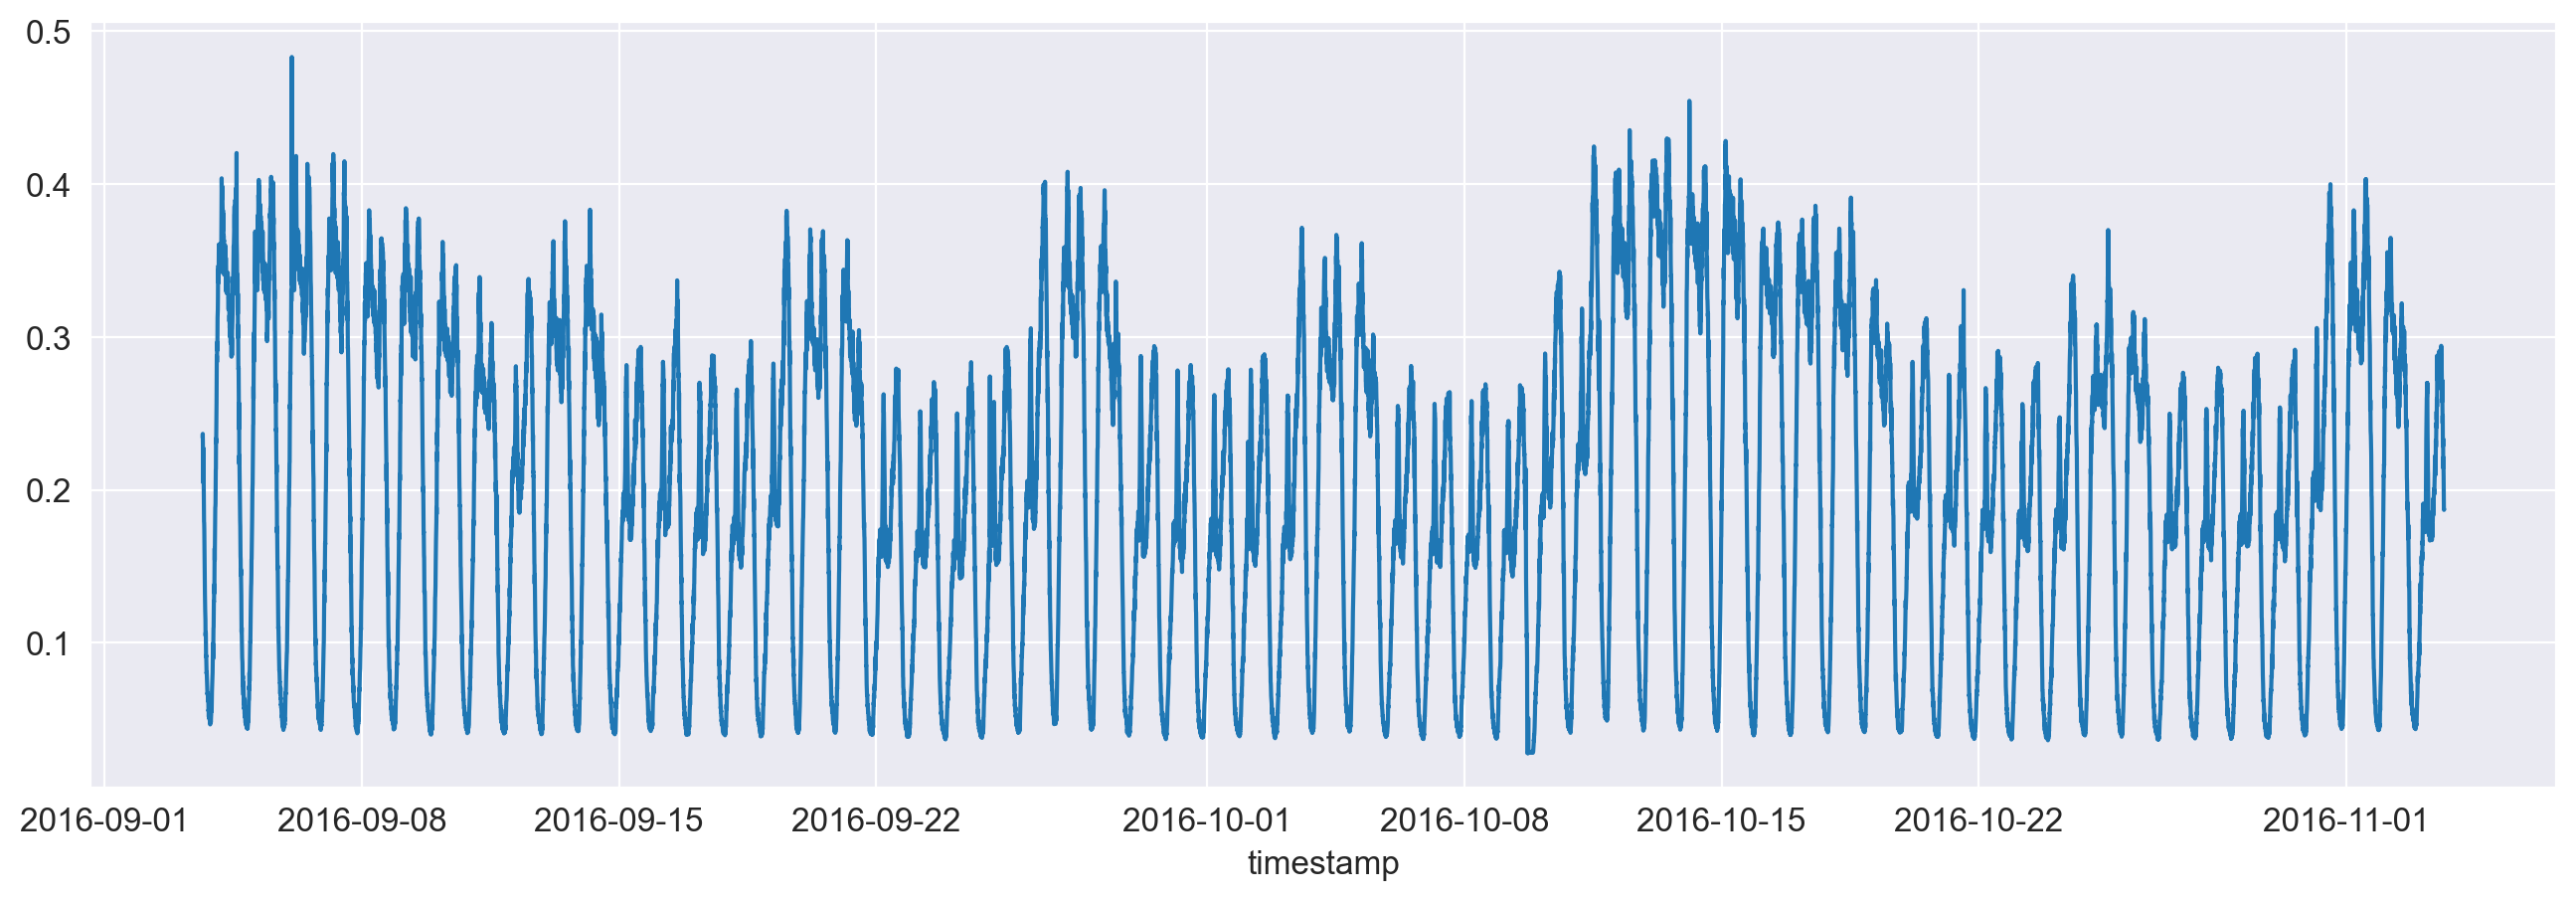

In [54]:
import pandas as pd

def download_time_series(path: str):
    res_time_series = pd.read_csv(path)
    res_time_series['timestamp'] = pd.to_datetime(res_time_series['timestamp'], unit='ms')
    res_time_series = res_time_series.set_index(res_time_series['timestamp'], drop=True)
    res_time_series = res_time_series.drop(columns=['timestamp'])
    return res_time_series

def draw(time_series):
    sns.lineplot(x=time_series.index, y=time_series['value_0'].values)

def topk_like(main_series, find_series, start, sz, k: int = 5):
    #main_series.value_0 = main_series.value_0.astype(float)
    #find_series.value_0 = find_series.value_0.astype(float)
    B = sz
    query = main_series["value_0"].values[start: start + B]
    other_series = find_series["value_0"].values  # 1
    distances = stumpy.mass(query, other_series)
    sorted_idx = np.argsort(distances)
    filtered_idx = []
    min_distance = B  # минимальное расстояние между началами паттернов

    for idx in sorted_idx:
        too_close = False
        for selected_idx in filtered_idx:
            if abs(idx - selected_idx) < min_distance:
                too_close = True
                break
        if not too_close:
            filtered_idx.append(idx)
        if len(filtered_idx) == k:
            break
    return filtered_idx, [distances[xi] for xi in filtered_idx]

time_series = download_time_series('time_series_bench_dataset/AIOPS/0efb375b-b902-3661-ab23-9a0bb799f4e3.csv')
#time_series2 = download_time_series('time_series_bench_dataset/AIOPS/1c6d7a26-1f1a-3321-bb4d-7a9d969ec8f0.csv')
time_series2 = time_series.copy()
time_series2.value_0 = time_series.value_0
draw(time_series)
sum(time_series.values[:,1])

In [56]:
START = 5000
SIZE = 2000
top3_idx, likelihood = topk_like(time_series, time_series2, START, SIZE, 3 + 1) # first one is poped as it is the start
top3_idx.pop(0)
print(top3_idx, likelihood, sep = '\n')

[np.int64(15080), np.int64(7016), np.int64(2984)]
[np.float64(2.9802322387695312e-06), np.float64(6.593017673321589), np.float64(8.722472933911883), np.float64(9.18514655459245)]


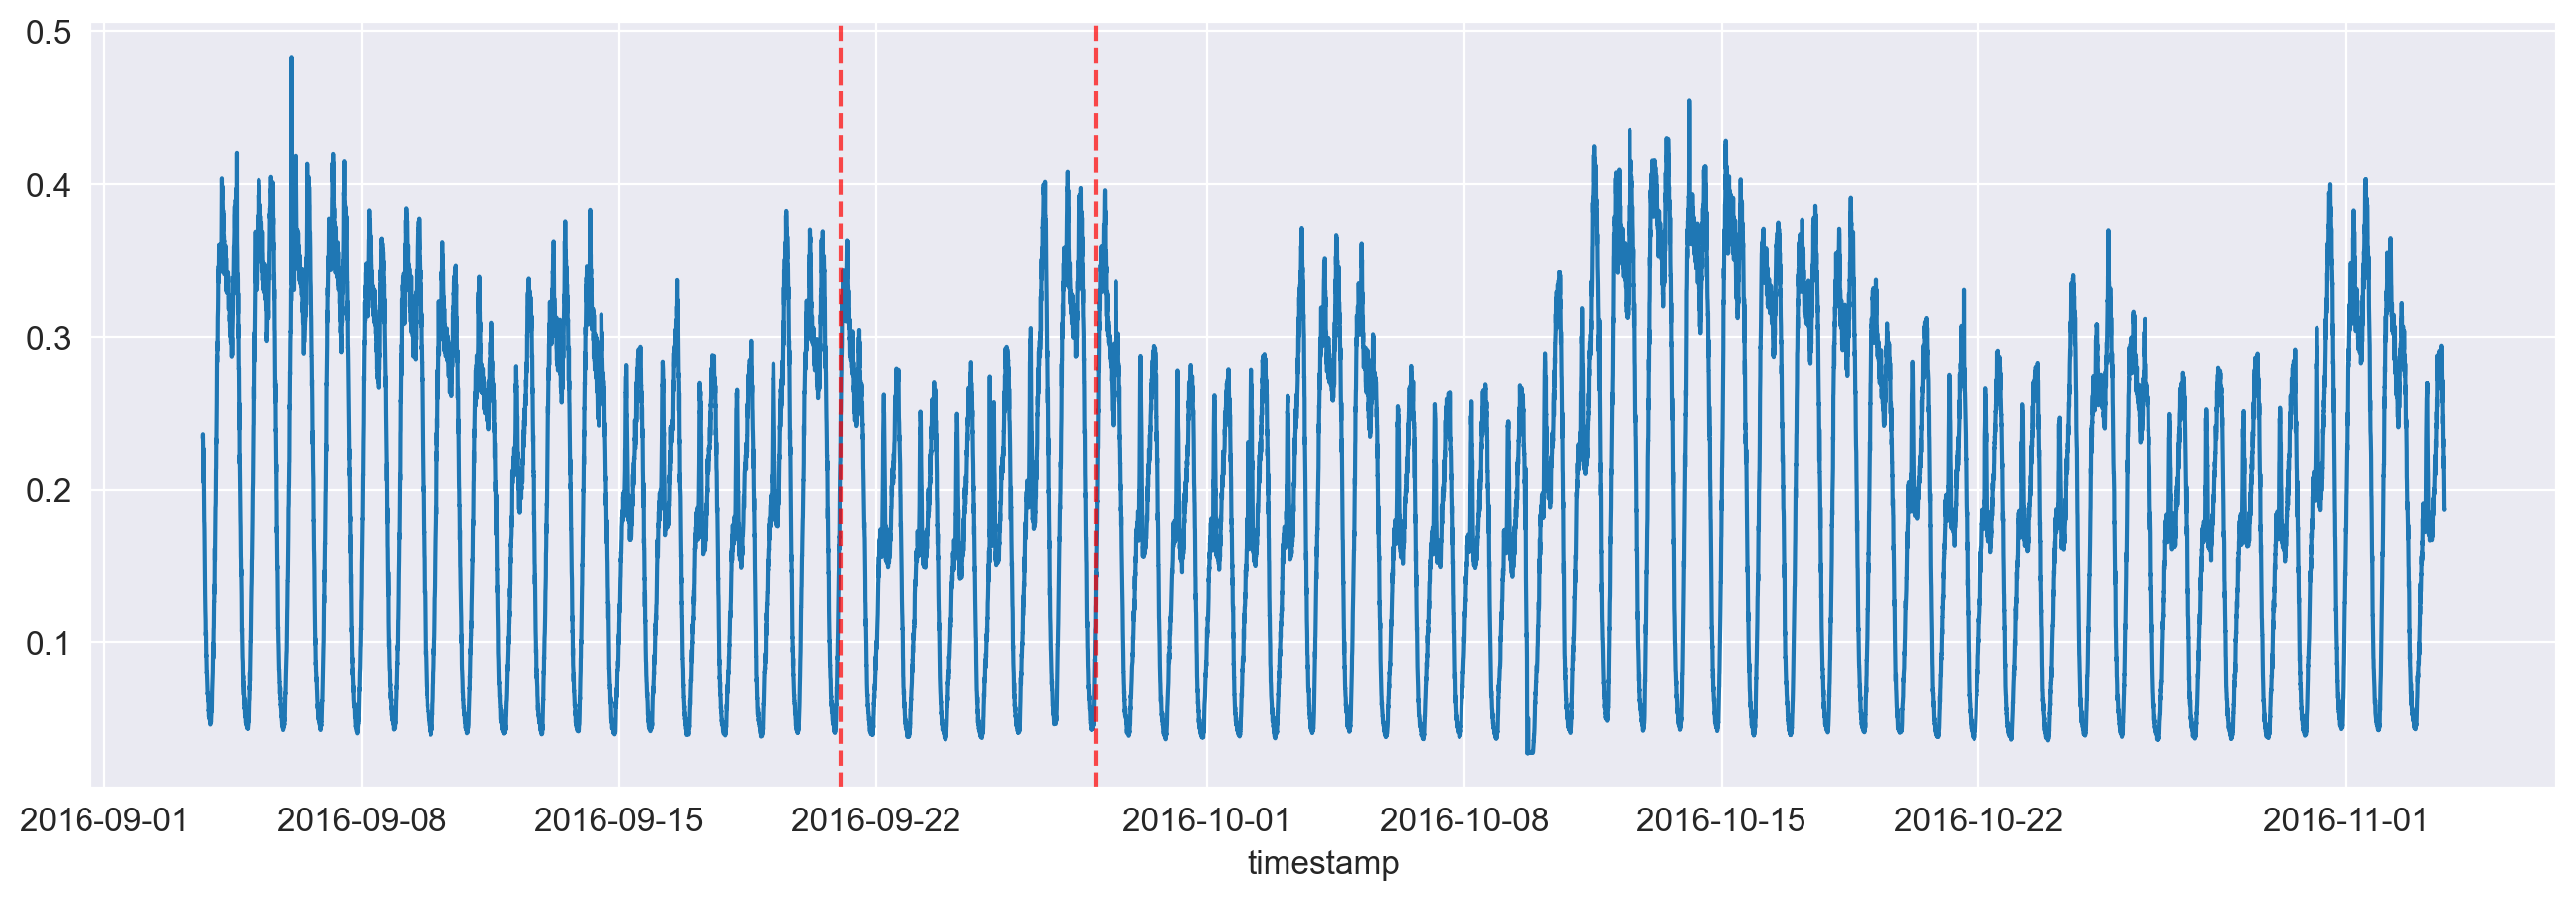

In [57]:
draw(time_series)
plt.axvline(x=time_series.index[START], color='red', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axvline(x=time_series.index[START + SIZE], color='red', linestyle='--', alpha=0.7, linewidth=1.5)

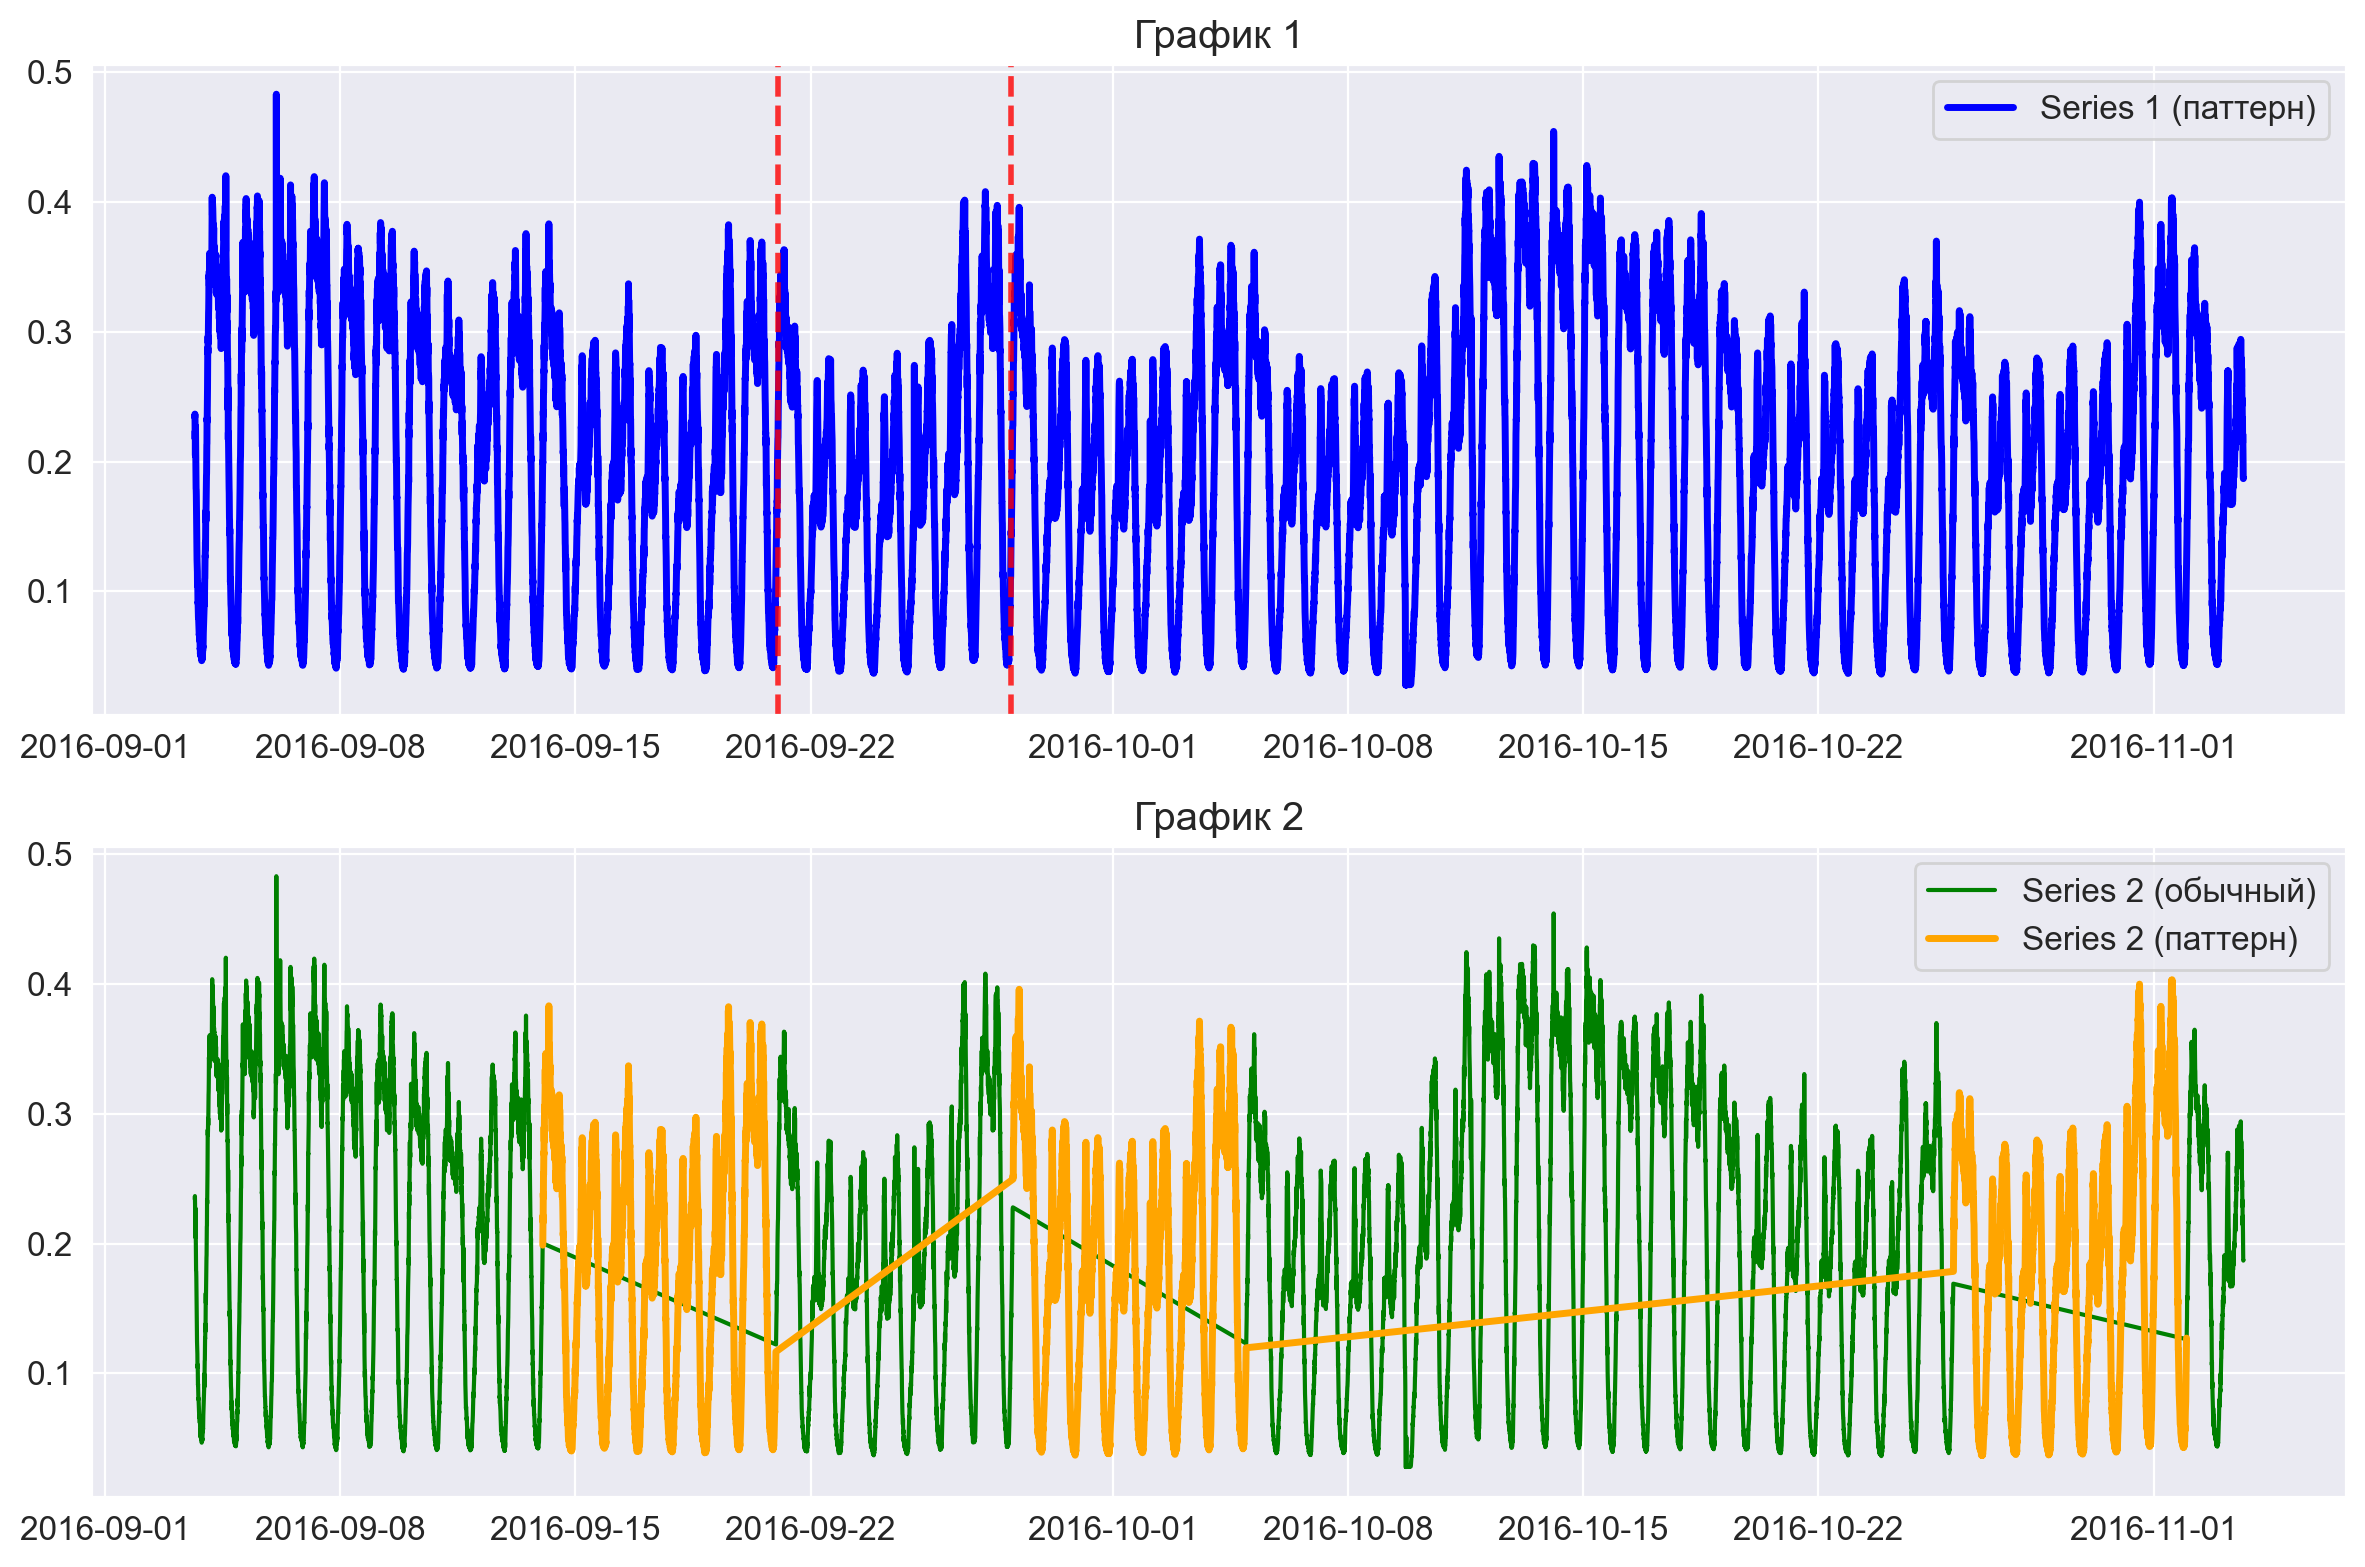

In [58]:
import matplotlib.pyplot as plt

# создаём 2 графика друг под другом
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Создаем маску для паттернов
mask = np.zeros(len(time_series2), dtype=bool)
for idx in top3_idx:
    mask[idx:idx + SIZE] = True

# Рисуем Series 1 с разными цветами
x1 = time_series.index
x2 = time_series2.index
y1 = time_series['value_0'].values
y2 = time_series2['value_0'].values

# ----- Первый график -----
ax1.plot(
    x1,
    y1,
    color='blue',
    linewidth=2.5,
    label='Series 1 (паттерн)'
)

ax1.set_title('График 1')
ax1.legend()
ax1.grid(True)

# красные вертикальные линии
ax1.axvline(
    x=time_series.index[START],
    color='red',
    linestyle='--',
    alpha=0.8,
    linewidth=2
)

ax1.axvline(
    x=time_series.index[START + SIZE],
    color='red',
    linestyle='--',
    alpha=0.8,
    linewidth=2
)

# ----- Второй график -----
ax2.plot(
    x2[~mask],
    y2[~mask],
    color='green',
    linewidth=1.5,
    label='Series 2 (обычный)'
)

ax2.plot(
    x2[mask],
    y2[mask],
    color='orange',
    linewidth=2.5,
    label='Series 2 (паттерн)'
)

ax2.set_title('График 2')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [59]:
# Создаем фигуру
fig = go.Figure()

# Добавляем основной график
fig.add_trace(go.Scatter(
    x=time_series2.index,
    y=time_series2['value_0'].values,
    mode='lines',
    name='Временной ряд',
    line=dict(color='steelblue', width=1.5)
))

# Добавляем вертикальные линии для каждого найденного паттерна
for idx in top3_idx:
    # Левая граница
    fig.add_vline(
        x=time_series2.index[idx],
        line_dash="dash",
        line_color="red",
        opacity=0.7,
        line_width=1.5
    )
    # Правая граница
    fig.add_vline(
        x=time_series2.index[idx + SIZE],
        line_dash="dash",
        line_color="red",
        opacity=0.7,
        line_width=1.5
    )

# Настройки оформления
fig.update_layout(
    title='Временной ряд с найденными паттернами',
    xaxis_title='Время',
    yaxis_title='Значение',
    hovermode='x unified',
    template='plotly_white',
    width=1200,
    height=600
)
fig.show()

np.float64(620.0)

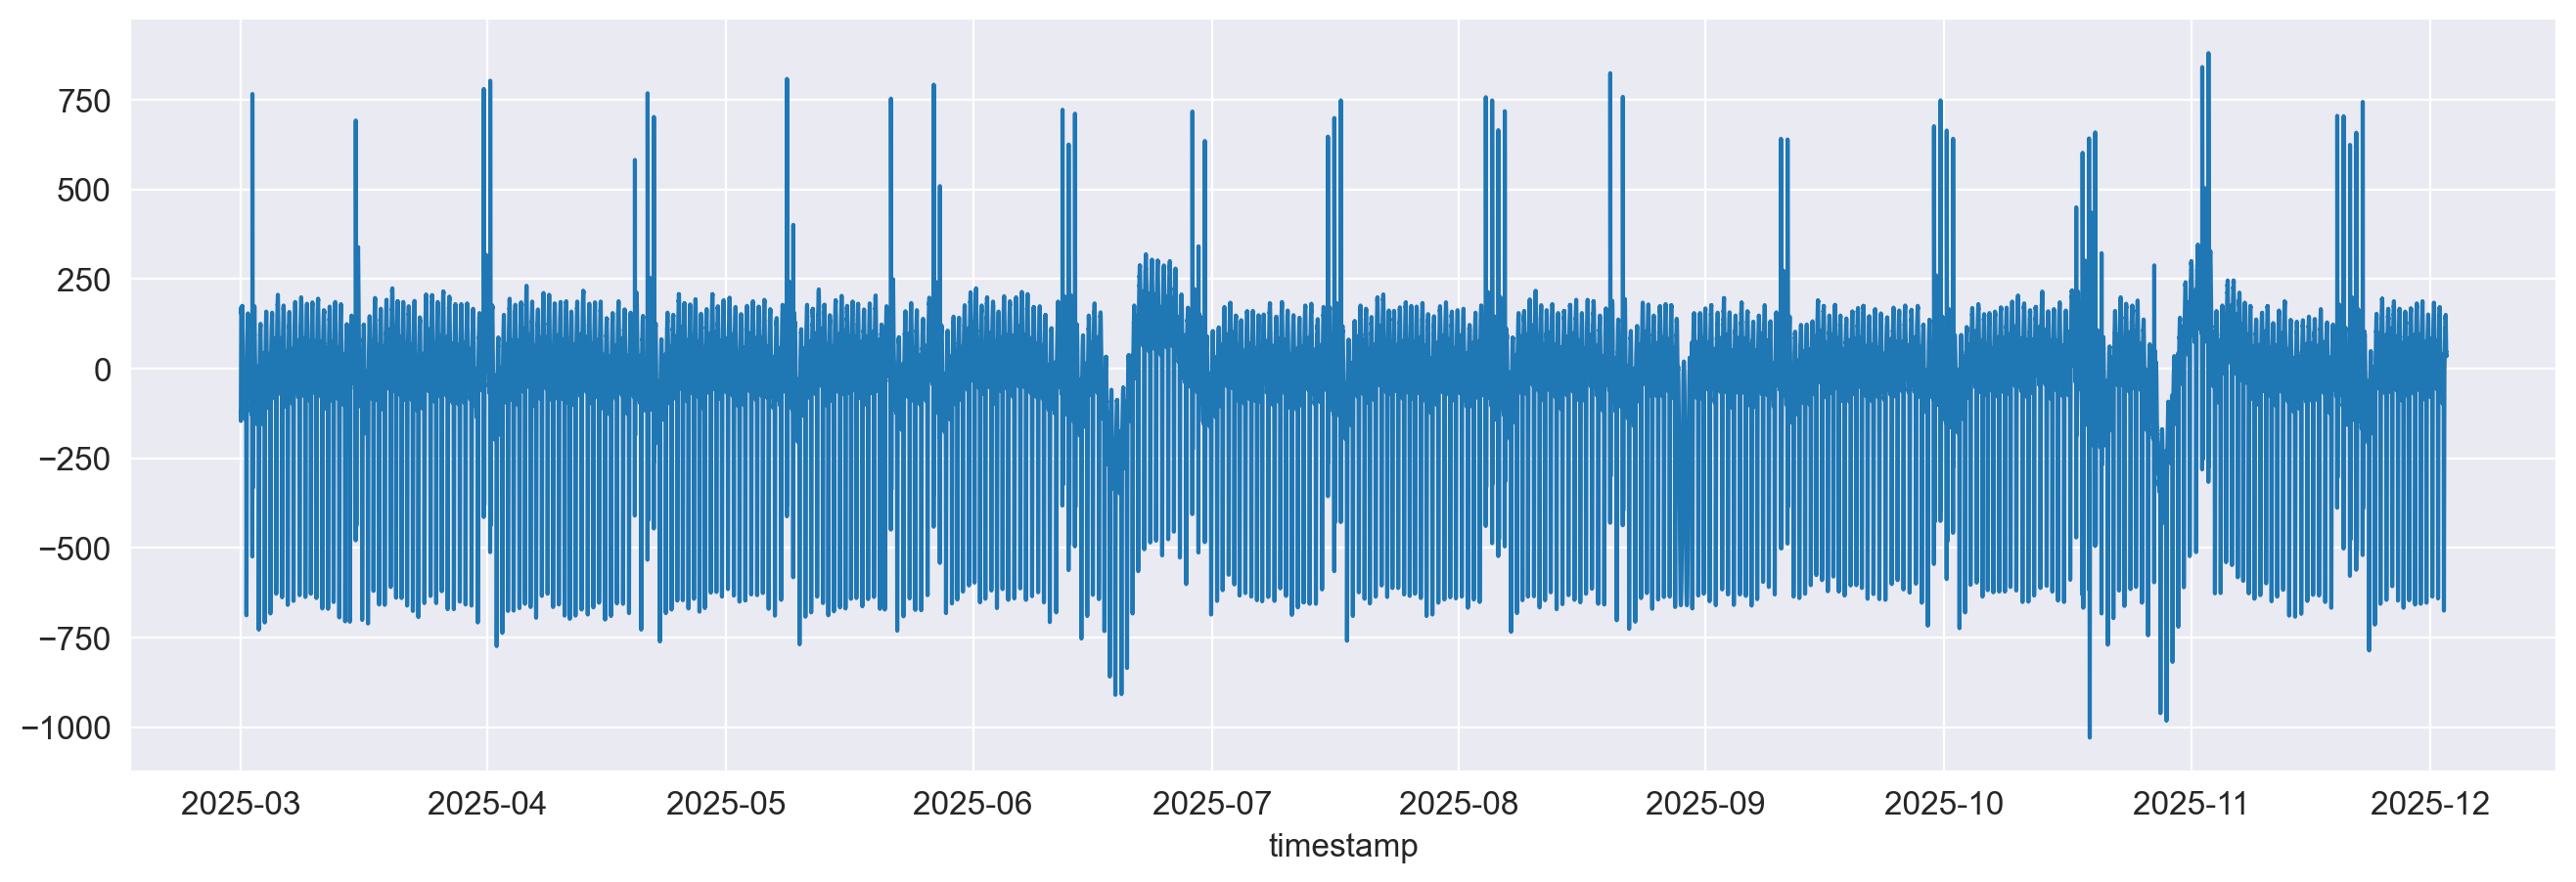

In [60]:
time_series = download_time_series('time_series_bench_dataset/UCR/1sddb40.csv')
time_series2 = download_time_series('time_series_bench_dataset/UCR/tiltAPB2.csv')
draw(time_series)
sum(time_series.values[:,1])

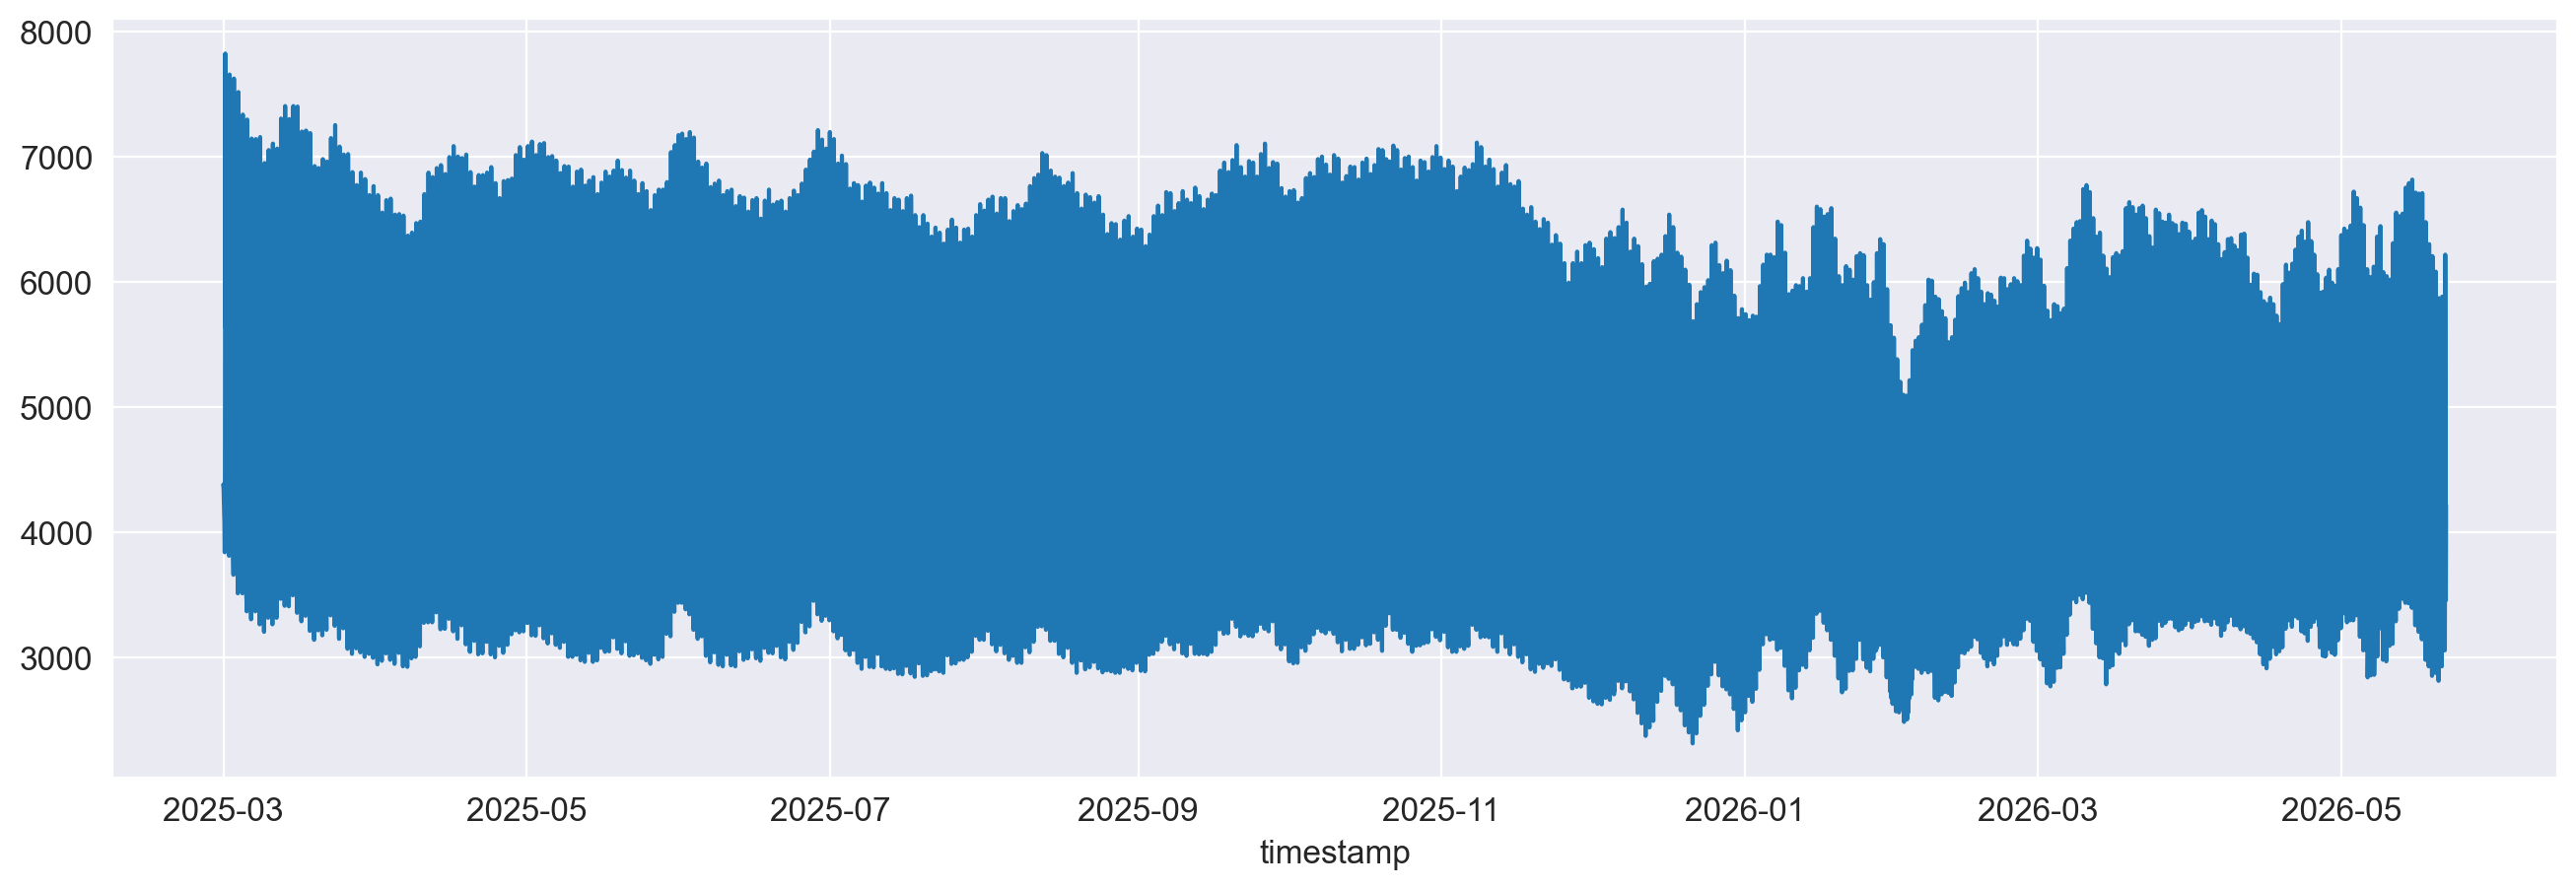

In [61]:
draw(time_series2)

In [62]:
START = 30000
SIZE = 4000
top3_idx, likelihood = topk_like(time_series, time_series2, START, SIZE, 3) # first one is poped as it is the start
print(top3_idx, likelihood, sep = '\n')

[np.int64(87095), np.int64(104393), np.int64(83071)]
[np.float64(69.63700846016401), np.float64(77.0102707842366), np.float64(77.13300596838681)]


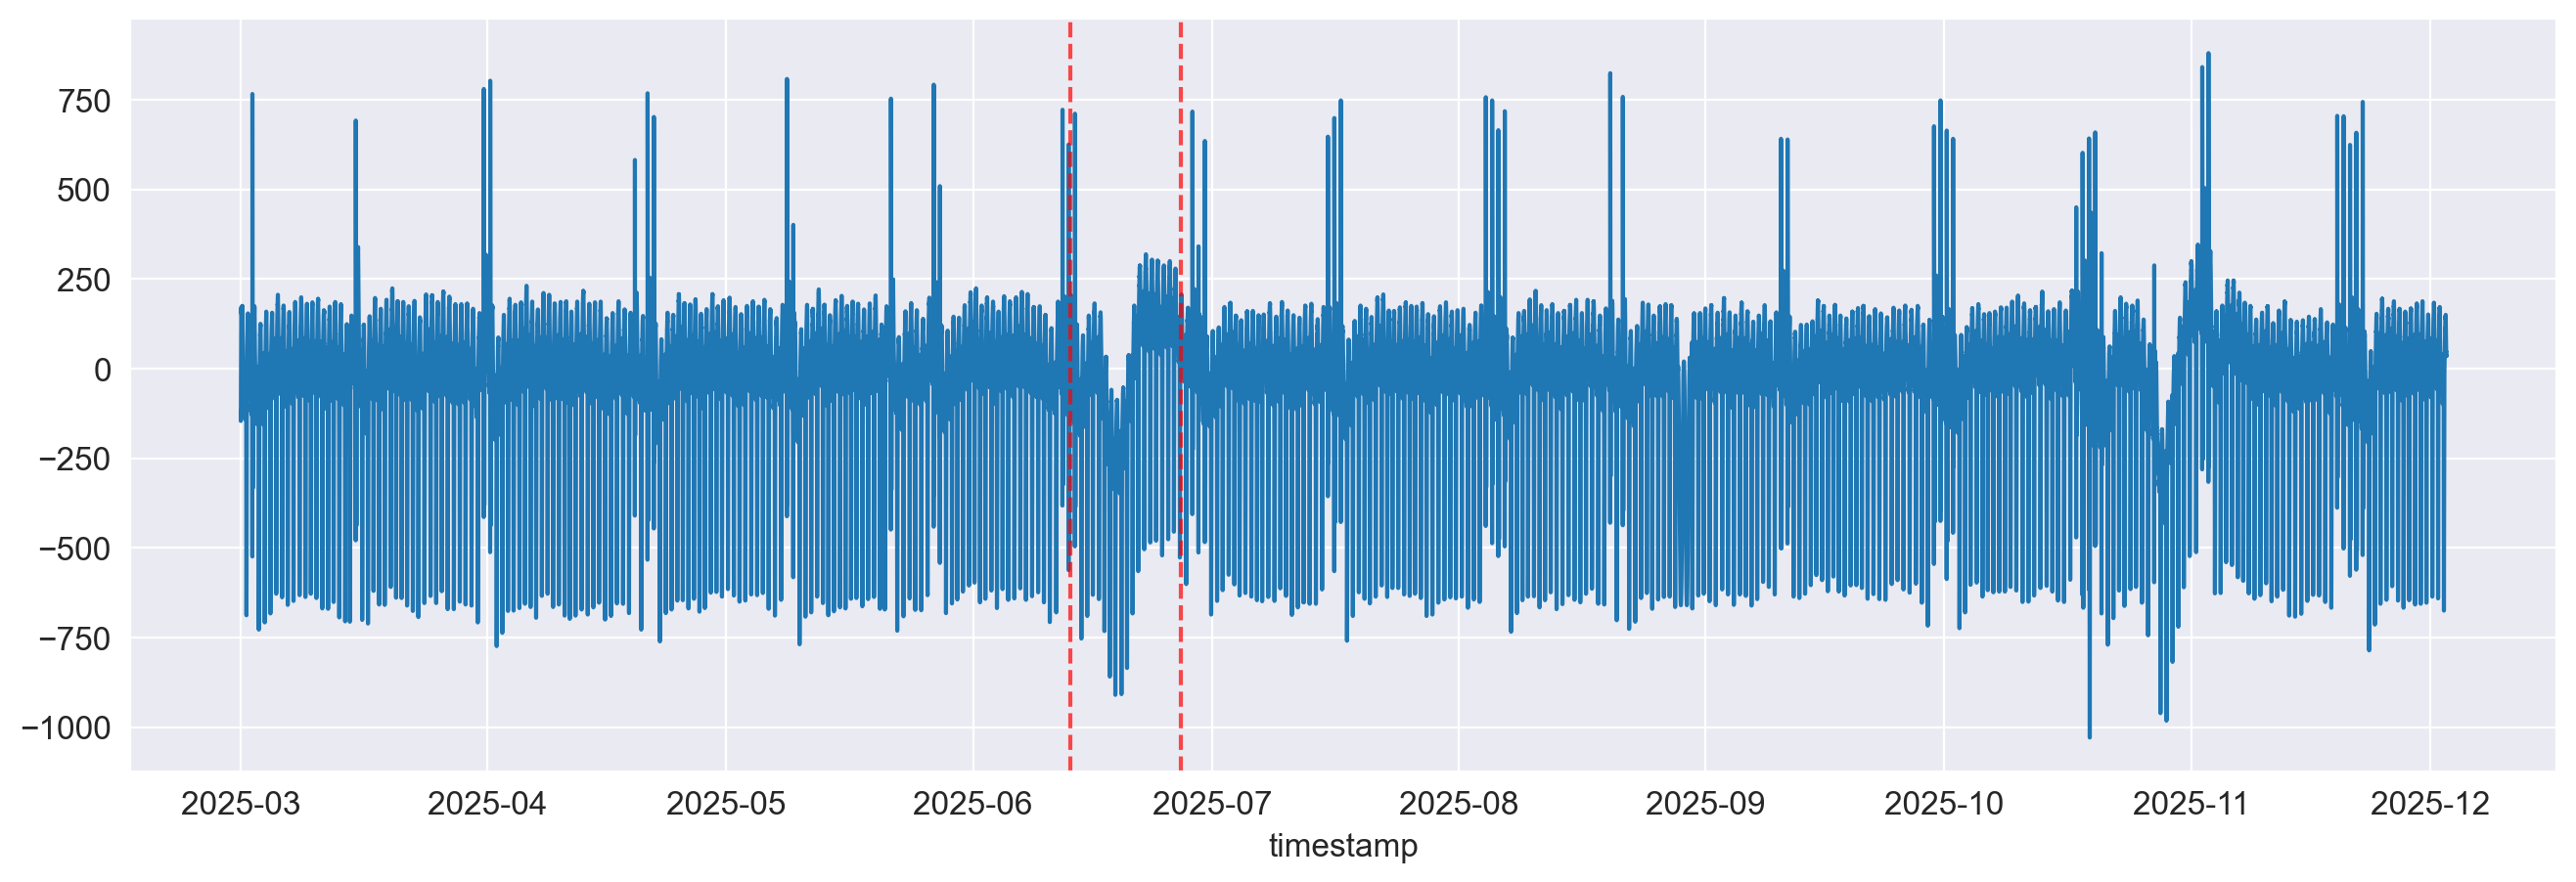

In [63]:
draw(time_series)
plt.axvline(x=time_series.index[START], color='red', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axvline(x=time_series.index[START + SIZE], color='red', linestyle='--', alpha=0.7, linewidth=1.5)

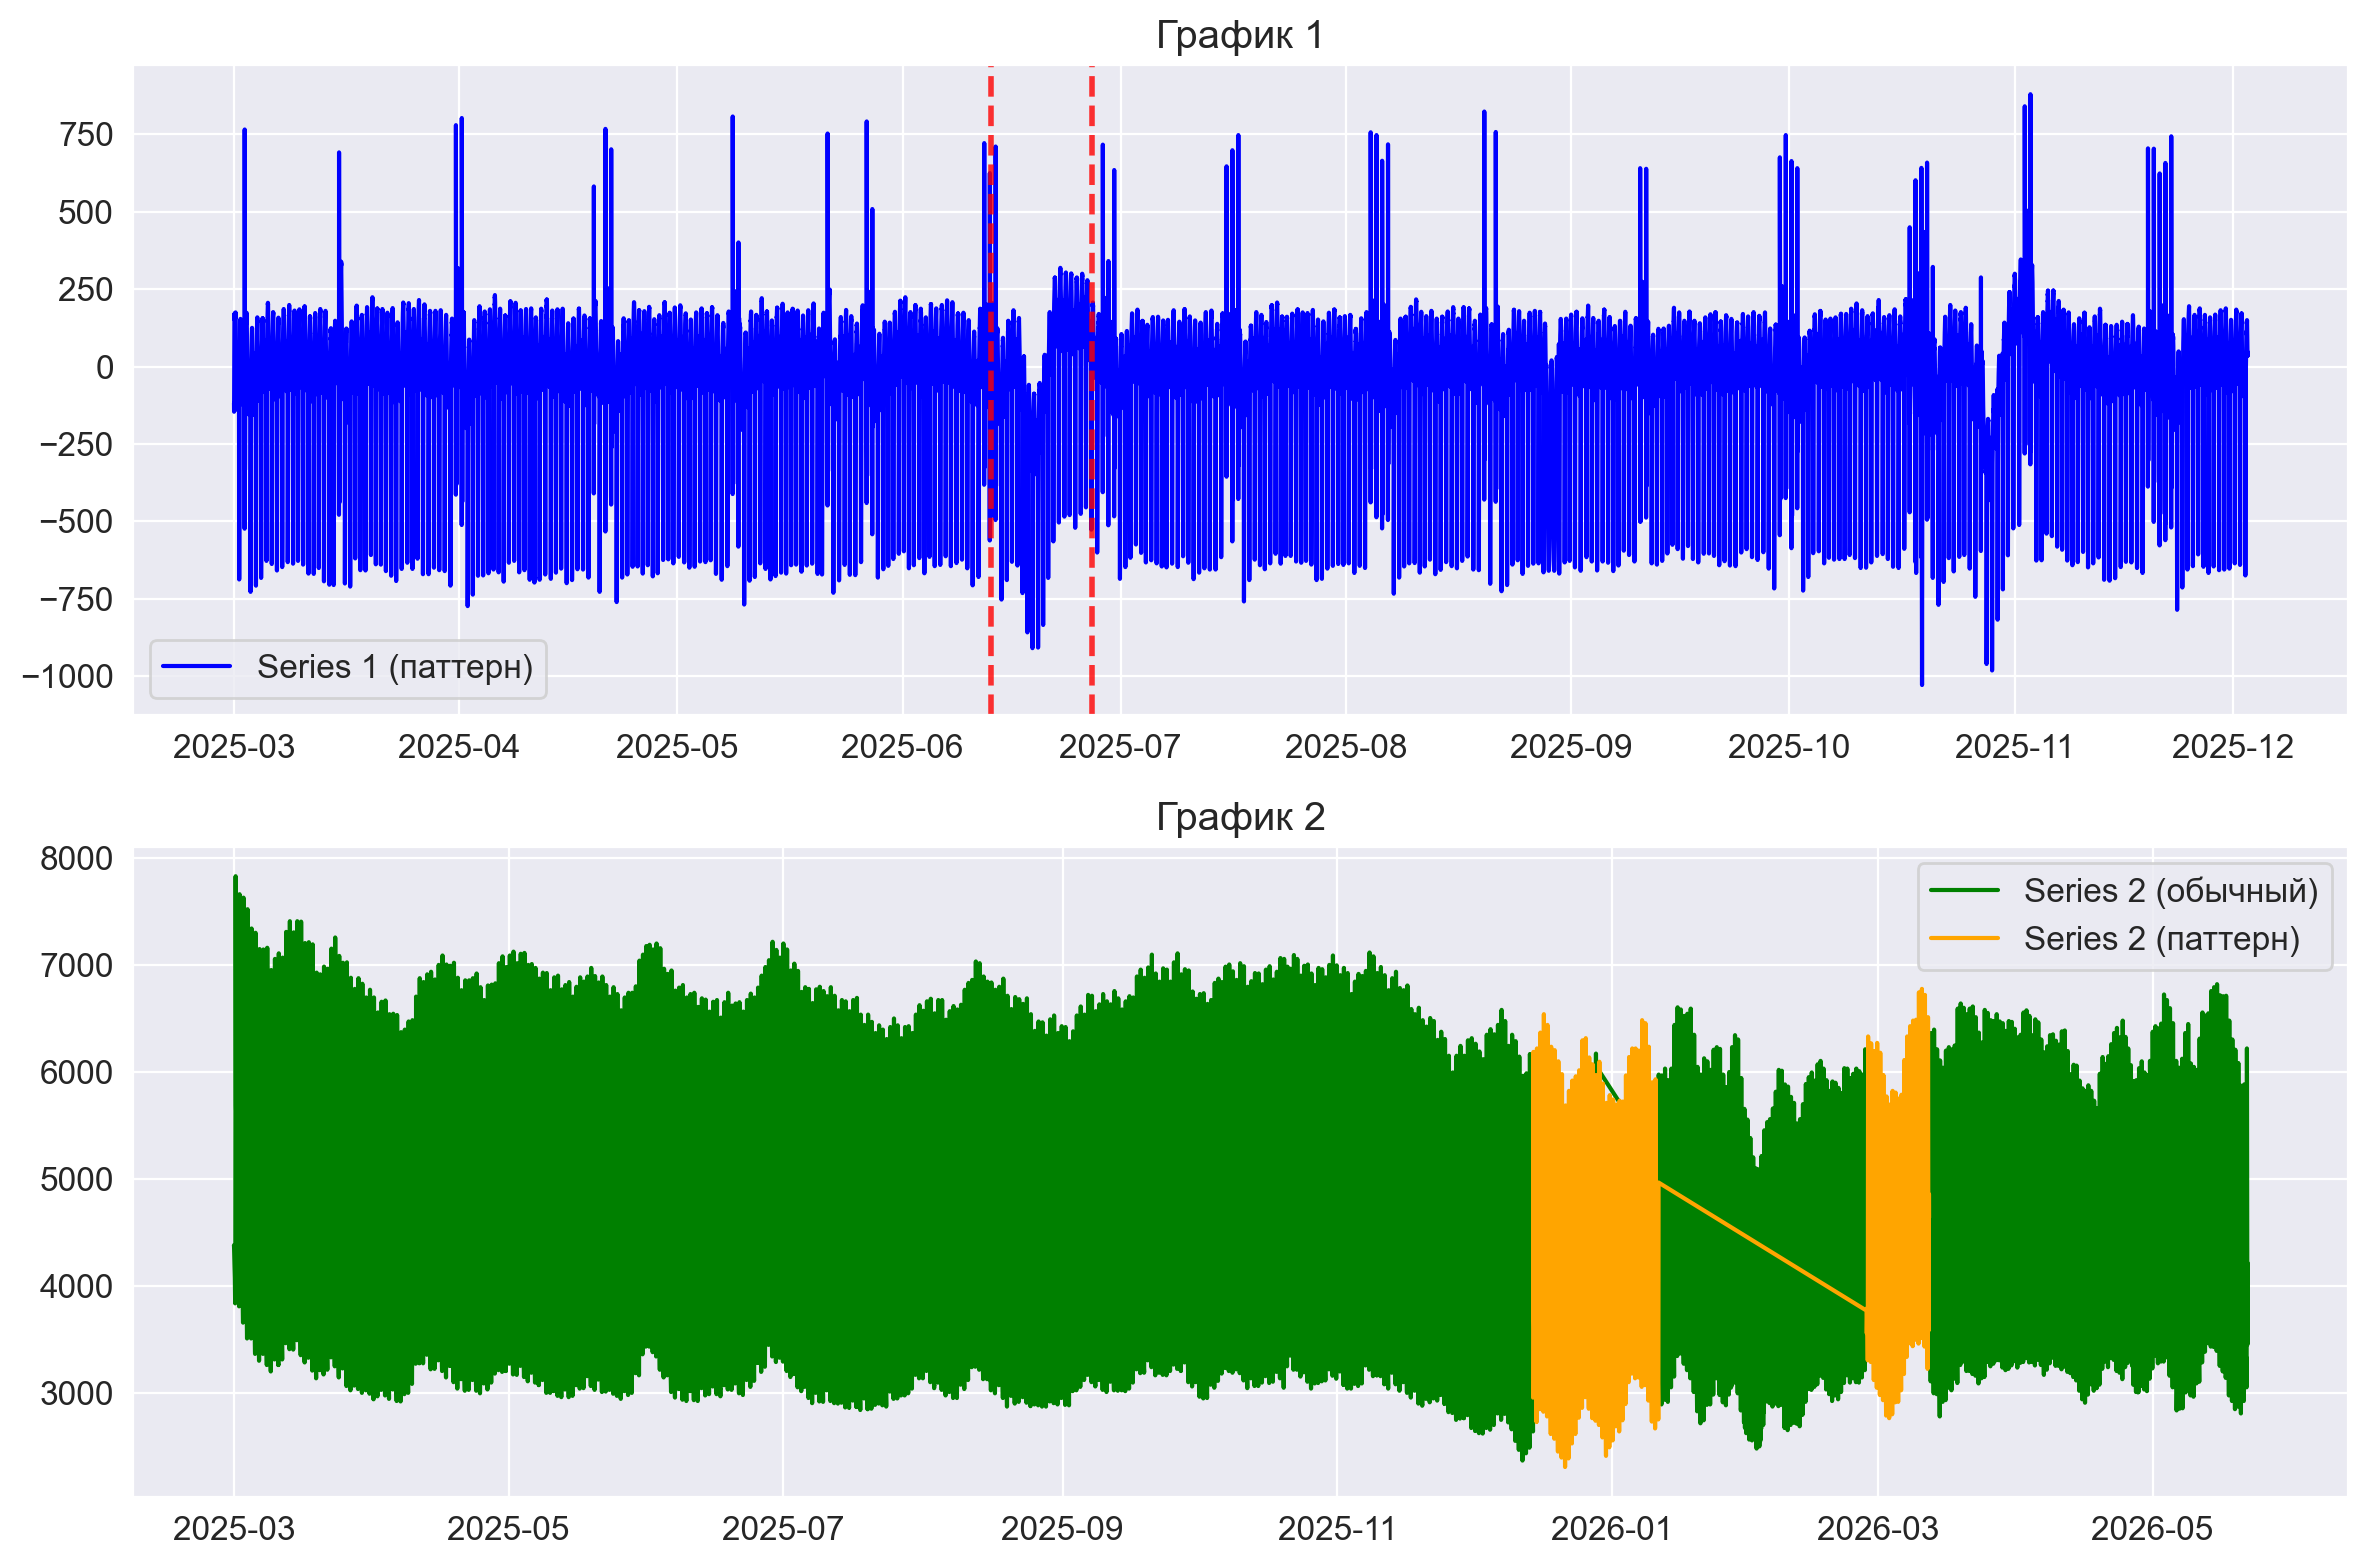

In [67]:
import matplotlib.pyplot as plt

# создаём 2 графика друг под другом
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Создаем маску для паттернов
mask = np.zeros(len(time_series2), dtype=bool)
for idx in top3_idx:
    mask[idx:idx + SIZE] = True

# Рисуем Series 1 с разными цветами
x1 = time_series.index
x2 = time_series2.index
y1 = time_series['value_0'].values
y2 = time_series2['value_0'].values

# ----- Первый график -----
ax1.plot(
    x1,
    y1,
    color='blue',
    linewidth=1.5,
    label='Series 1 (паттерн)'
)

ax1.set_title('График 1')
ax1.legend()
ax1.grid(True)

# красные вертикальные линии
ax1.axvline(
    x=time_series.index[START],
    color='red',
    linestyle='--',
    alpha=0.8,
    linewidth=2
)

ax1.axvline(
    x=time_series.index[START + SIZE],
    color='red',
    linestyle='--',
    alpha=0.8,
    linewidth=2
)

# ----- Второй график -----
ax2.plot(
    x2[~mask],
    y2[~mask],
    color='green',
    linewidth=1.5,
    label='Series 2 (обычный)'
)

ax2.plot(
    x2[mask],
    y2[mask],
    color='orange',
    linewidth=1.5,
    label='Series 2 (паттерн)'
)

ax2.set_title('График 2')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [68]:
START = 67676
SIZE = 4000
top3_idx, likelihood = topk_like(time_series, time_series2, START, SIZE, 3) # first one is poped as it is the start
print(top3_idx, likelihood, sep = '\n')

[np.int64(85920), np.int64(104328), np.int64(23457)]
[np.float64(71.55219238726153), np.float64(76.5152717905297), np.float64(78.17861696352617)]


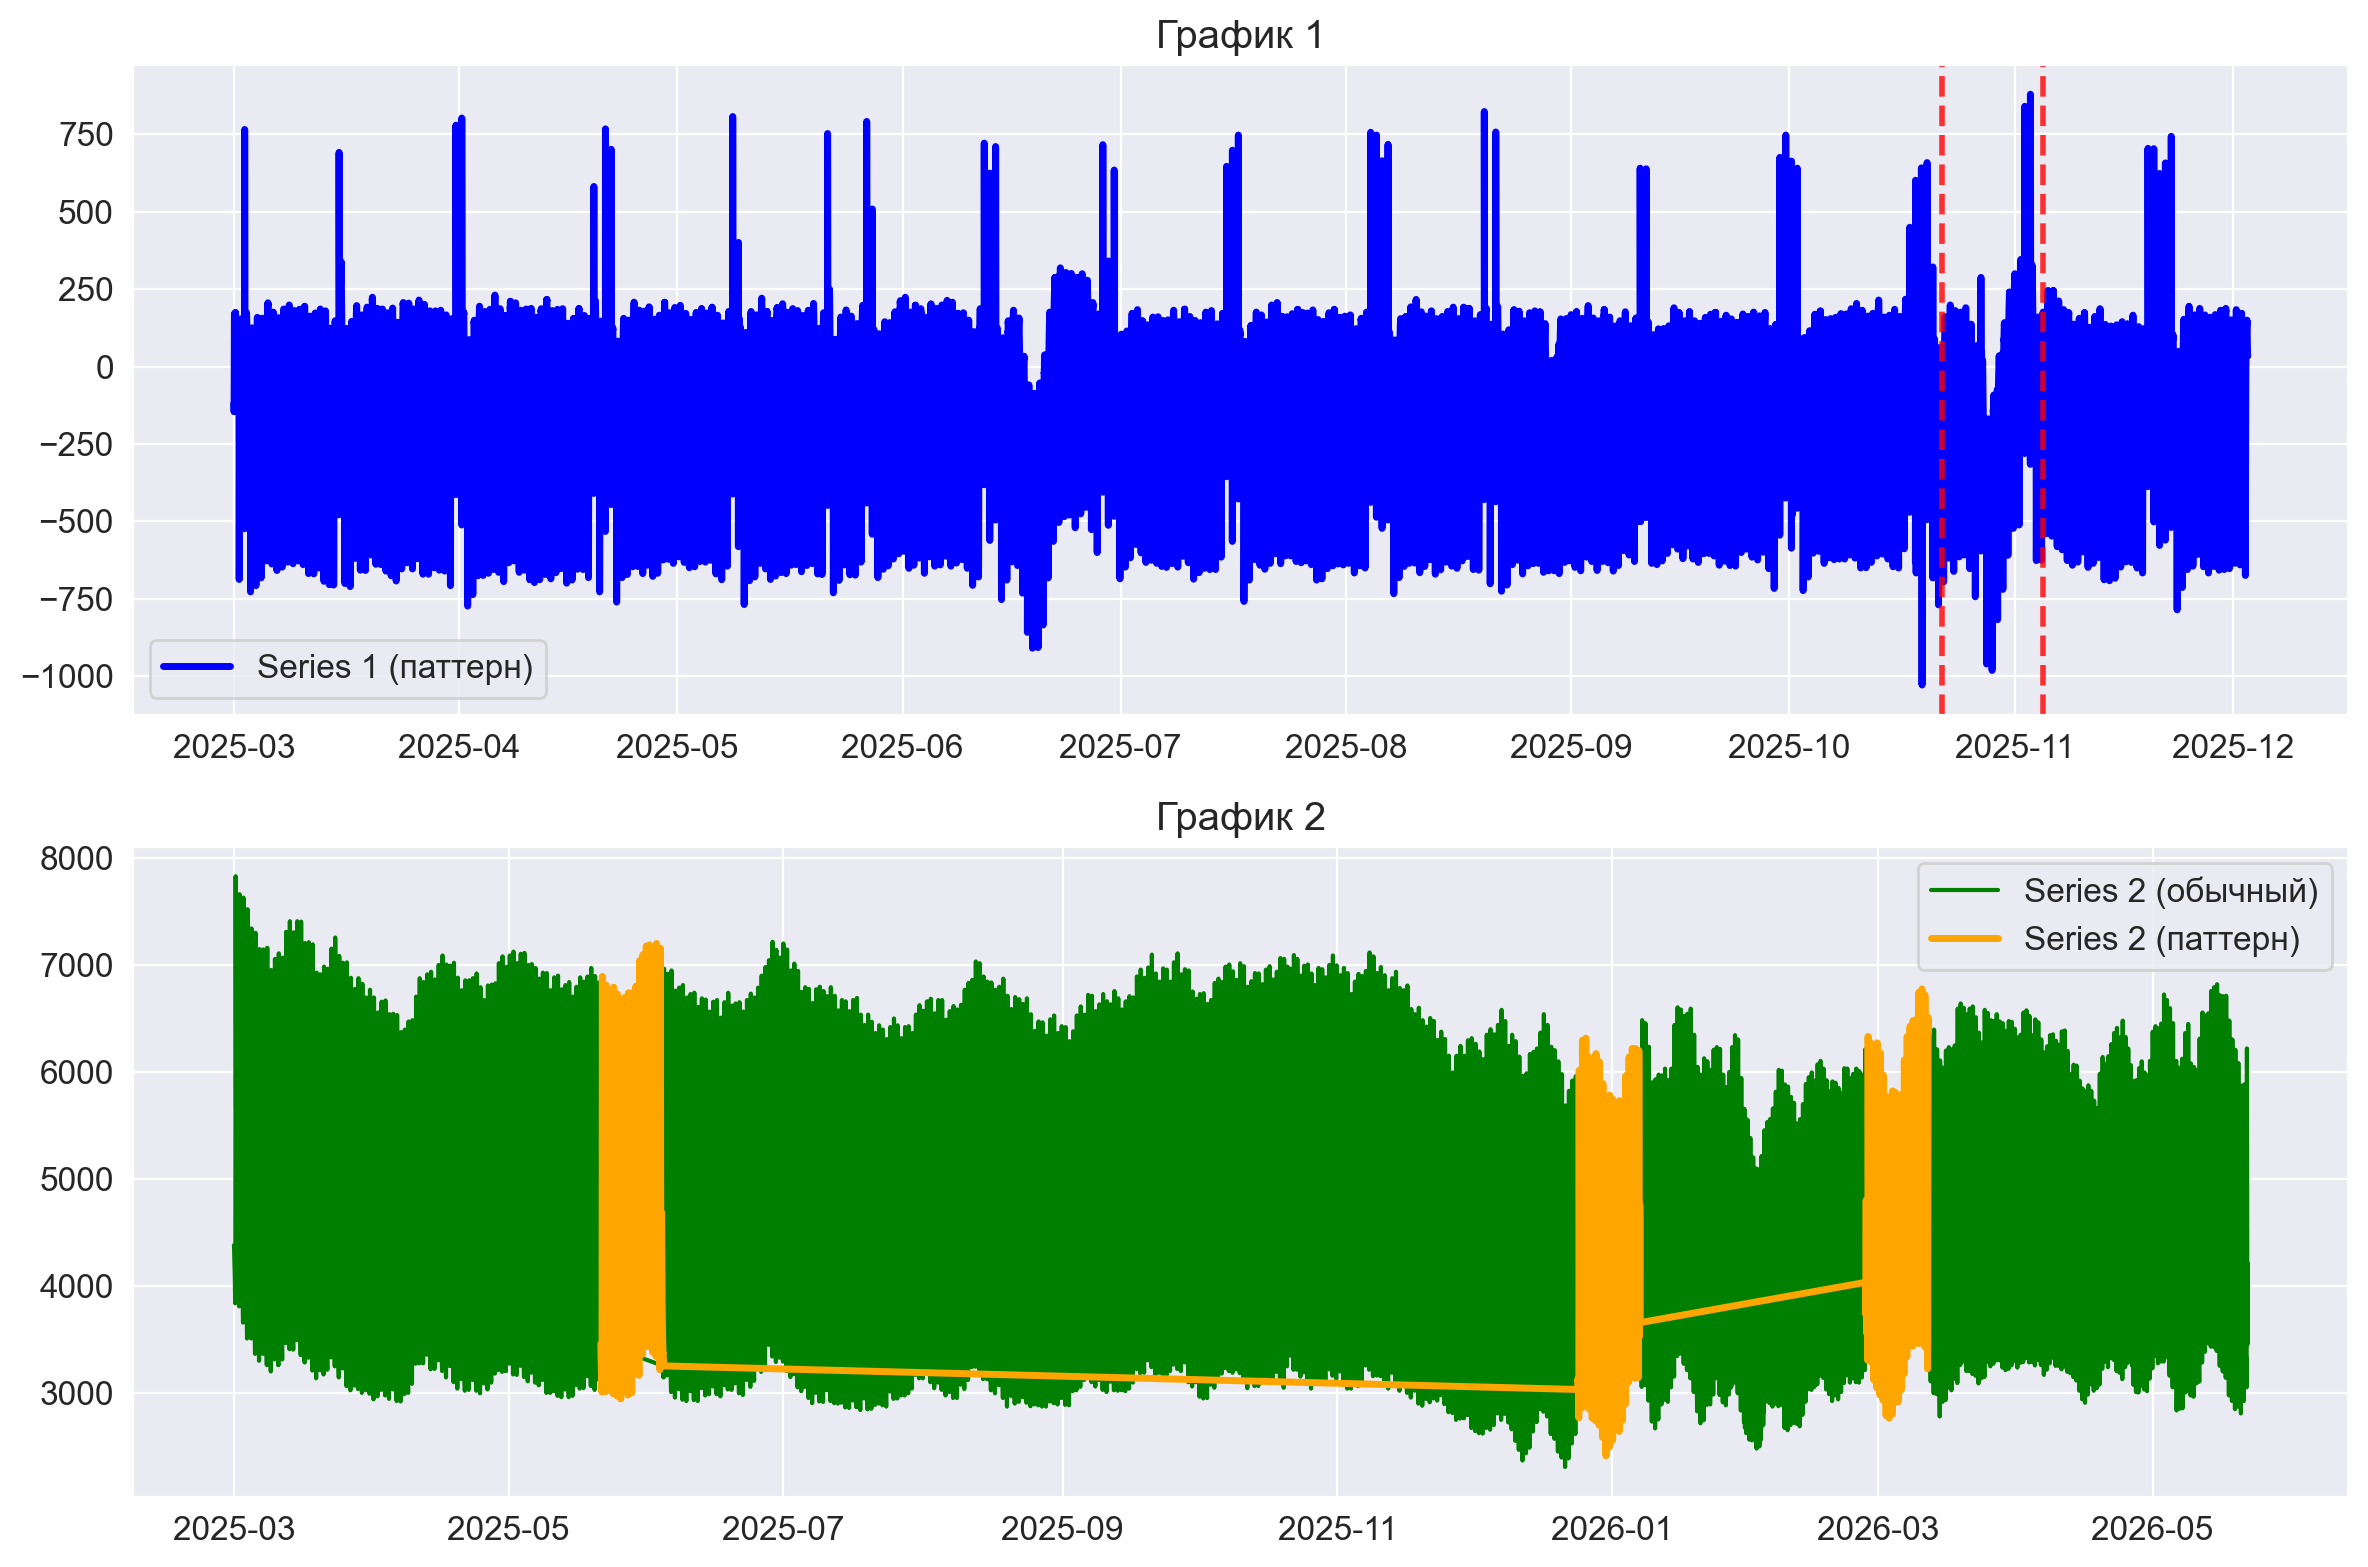

In [69]:
import matplotlib.pyplot as plt

# создаём 2 графика друг под другом
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Создаем маску для паттернов
mask = np.zeros(len(time_series2), dtype=bool)
for idx in top3_idx:
    mask[idx:idx + SIZE] = True

# Рисуем Series 1 с разными цветами
x1 = time_series.index
x2 = time_series2.index
y1 = time_series['value_0'].values
y2 = time_series2['value_0'].values

# ----- Первый график -----
ax1.plot(
    x1,
    y1,
    color='blue',
    linewidth=2.5,
    label='Series 1 (паттерн)'
)

ax1.set_title('График 1')
ax1.legend()
ax1.grid(True)

# красные вертикальные линии
ax1.axvline(
    x=time_series.index[START],
    color='red',
    linestyle='--',
    alpha=0.8,
    linewidth=2
)

ax1.axvline(
    x=time_series.index[START + SIZE],
    color='red',
    linestyle='--',
    alpha=0.8,
    linewidth=2
)

# ----- Второй график -----
ax2.plot(
    x2[~mask],
    y2[~mask],
    color='green',
    linewidth=1.5,
    label='Series 2 (обычный)'
)

ax2.plot(
    x2[mask],
    y2[mask],
    color='orange',
    linewidth=2.5,
    label='Series 2 (паттерн)'
)

ax2.set_title('График 2')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

np.float64(620.0)

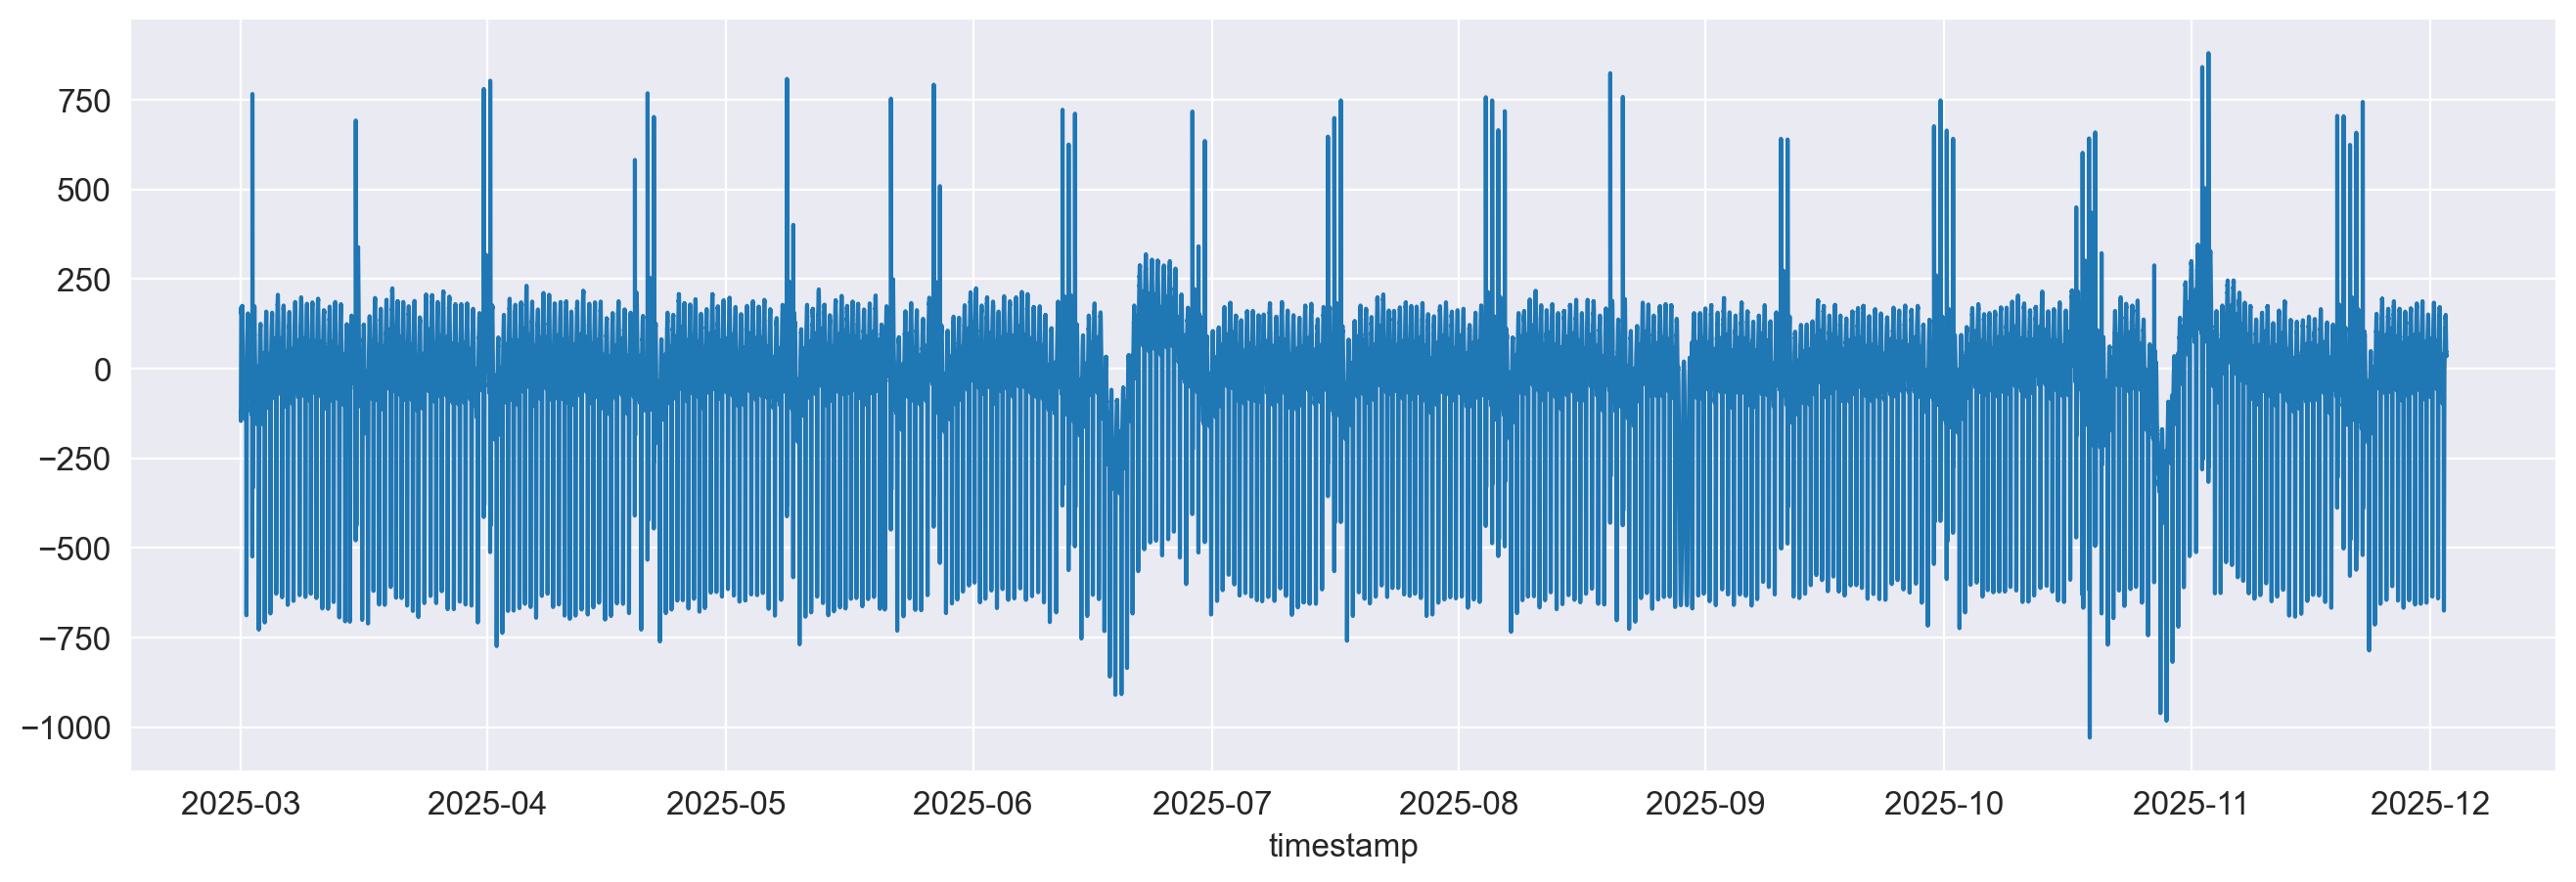

In [70]:
time_series = download_time_series('time_series_bench_dataset/UCR/1sddb40.csv')
time_series2 = download_time_series('time_series_bench_dataset/UCR/NOISECIMIS44AirTemperature4.csv')
draw(time_series)
sum(time_series.values[:,1])

In [95]:
START = 67676
SIZE = 4000
SIZE2 = SIZE / 2
top3_idx, likelihood = topk_like(time_series, time_series2, START, SIZE2, 3) # first one is poped as it is the start
print(top3_idx, likelihood, sep = '\n')

TypeError: slice indices must be integers or None or have an __index__ method

TypeError: slice indices must be integers or None or have an __index__ method

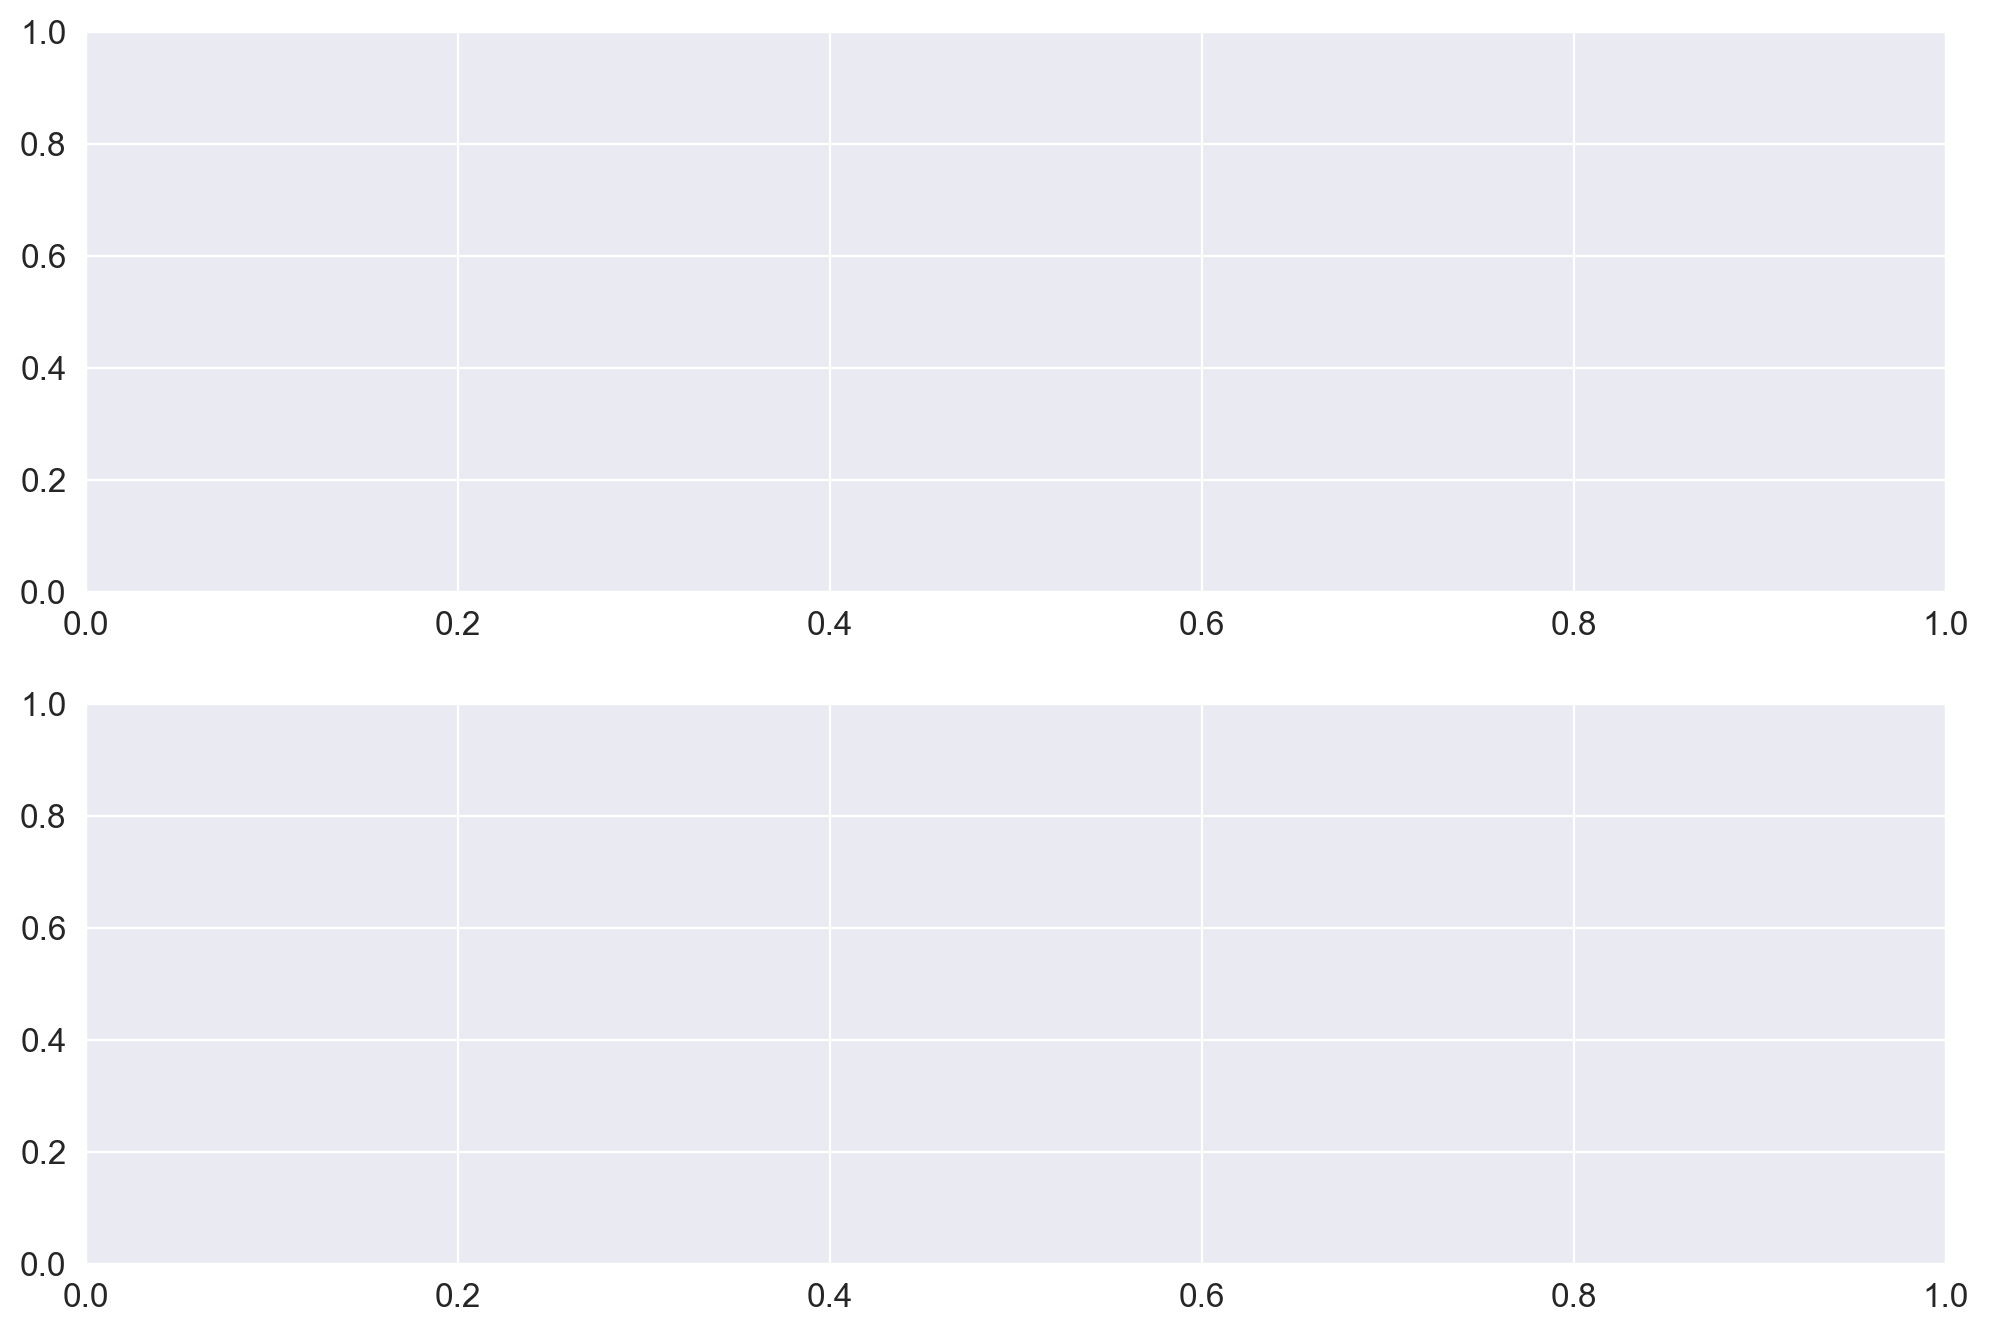

In [96]:
import matplotlib.pyplot as plt

# создаём 2 графика друг под другом
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Создаем маску для паттернов
mask = np.zeros(len(time_series2), dtype=bool)
for idx in top3_idx:
    mask[idx:idx + SIZE2] = True

# Рисуем Series 1 с разными цветами
x1 = time_series.index
x2 = time_series2.index
y1 = time_series['value_0'].values
y2 = time_series2['value_0'].values

# ----- Первый график -----
ax1.plot(
    x1,
    y1,
    color='blue',
    linewidth=2.5,
    label='Series 1 (паттерн)'
)

ax1.set_title('График 1')
ax1.legend()
ax1.grid(True)

# красные вертикальные линии
ax1.axvline(
    x=time_series.index[START],
    color='red',
    linestyle='--',
    alpha=0.8,
    linewidth=2
)

ax1.axvline(
    x=time_series.index[START + SIZE],
    color='red',
    linestyle='--',
    alpha=0.8,
    linewidth=2
)

# ----- Второй график -----
ax2.plot(
    x2[~mask],
    y2[~mask],
    color='green',
    linewidth=1.5,
    label='Series 2 (обычный)'
)

ax2.plot(
    x2[mask],
    y2[mask],
    color='orange',
    linewidth=2.5,
    label='Series 2 (паттерн)'
)

ax2.set_title('График 2')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()